# GEDI Canopy Cover Pipeline and The Bayesian Statistical Approach

This notebook processes NASA GEDI Level 2B HDF5 files stored in S3 through four sequential phases:

| Phase | Description |
|---|---|
| **Phase 1** | High-performance batch extraction of GEDI shots from S3 |
| **Phase 1a** | Year parsing from GEDI filenames |
| **Phase 1b** | Harmonization to the SMAP 9 km grid |
| **Phase 1c** | Spatial join to assign shots to study-area jurisdictions |

**Source:** `s3://central-virginia-tree-canopy-project/GEDI/GEDI02_B/002/`  
**Final output:** `s3://central-virginia-tree-canopy-project/gedi02B-county-summary/virginia_gedi02B_county_summary.csv`

## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

# Pin the entire boto stack atomically — all four packages must be compatible
boto_stack = [
    "botocore==1.43.0",
    "boto3==1.43.0",
    "s3fs==2026.6.0",
]

# Install boto stack with --no-deps to prevent pip from overriding the pins
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                       "--force-reinstall"] + boto_stack)

# Install all other dependencies normally
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                       "h5py", "numpy", "pandas", "pymc", "arviz", "ipywidgets", "seaborn"])

print("Boto Stack and all dependencies installed.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.42 requires botocore==1.43.42, but you have botocore 1.43.0 which is incompatible.
awscli 1.45.42 requires s3transfer<0.20.0,>=0.19.0, but you have s3transfer 0.17.1 which is incompatible.
sagemaker 2.257.3 requires attrs<26,>=24, but you have attrs 26.1.0 which is incompatible.


Boto Stack and all dependencies installed.


In [2]:
#import subprocess, sys

#packages = ["s3fs", "h5py", "numpy", "pandas", "pymc", "arviz", "ipywidgets", "seaborn" ]
#subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)
#print("All dependencies installed.")

## Cell 2 — Imports

In [3]:
import os
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns  # Optional, but makes probability density curves smoother

print("Imports successful.")

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Imports successful.


## Cell 3 — Configuration

When necessary, edit this cell to change S3 paths, bounding box, grid resolution, or target jurisdictions.

In [4]:
# ── S3 settings ───────────────────────────────────────────────────────────────
S3_BUCKET                = "central-virginia-tree-canopy-project/"
GEDI02A_COUNTY_S3_PREFIX = "gedi-county-summary/"
SMAP_S3_PREFIX           = "dashboard-data/"

# ── Local output directory ────────────────────────────────────────────────────
OUTPUT_DIR        = "/home/ec2-user/SageMaker/gedi_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded.")
print(f"  GEDI02_A source file  : s3://{S3_BUCKET}/{GEDI02A_COUNTY_S3_PREFIX}")
print(f"  Output dir   : {OUTPUT_DIR}")
print(f"  S3 output    : s3://{S3_BUCKET}/{GEDI02A_COUNTY_S3_PREFIX}")

Configuration loaded.
  GEDI02_A source file  : s3://central-virginia-tree-canopy-project//gedi-county-summary/
  Output dir   : /home/ec2-user/SageMaker/gedi_output
  S3 output    : s3://central-virginia-tree-canopy-project//gedi-county-summary/


## Cell 4 — Load a CSV Data File

In [5]:

# Define the S3 path
s3_uri = "s3://" + S3_BUCKET + GEDI02A_COUNTY_S3_PREFIX + "virginia_gedi_county_summary.csv"
print(f"s3_uri: {s3_uri}")

# Load directly into pandas
df_gedi = pd.read_csv(s3_uri)

# Preview the data
df_gedi.head()


s3_uri: s3://central-virginia-tree-canopy-project/gedi-county-summary/virginia_gedi_county_summary.csv


,year,jurisdiction,canopy_height_mean_m
0,2019,Albemarle,19.675812
1,2019,Augusta,14.742975
2,2019,Buckingham,16.031614
3,2019,Charlottesville,16.583230
4,2019,Fluvanna,18.198132


## Cell 4a — Load a JSON Data File

In [6]:
# Define the S3 path
#s3_json_uri = "s3://" + S3_BUCKET + SMAP_S3_PREFIX + "pearson_r_matrix.json"
s3_json_uri = "s3://" + S3_BUCKET + SMAP_S3_PREFIX + "merged_smap_gedi.json"
#s3_json_uri = "s3://" + S3_BUCKET + SMAP_S3_PREFIX + "merged_smap_gedi02B.json"

print(f"s3_json_uri: {s3_json_uri}")

# Load directly into a pandas DataFrame
df_matrix = pd.read_json(s3_json_uri)

# Preview the matrix data
df_matrix.head()

s3_json_uri: s3://central-virginia-tree-canopy-project/dashboard-data/merged_smap_gedi.json


,year,jurisdiction,canopy_height_mean_m,sm_mean_m3m3,sm_min,sm_max,sm_std,sm_mean_lag1,sm_mean_lag2
0,2019,Albemarle,19.675812,0.379557,0.314088,0.436462,0.027698,NaN,NaN
1,2020,Albemarle,18.465603,0.307442,0.229515,0.389360,0.034866,0.379557,NaN
2,2021,Albemarle,18.793875,0.287135,0.214029,0.363267,0.033156,0.307442,0.379557
3,2022,Albemarle,18.639362,0.288770,0.218431,0.366198,0.033531,0.287135,0.307442
4,2023,Albemarle,13.609988,0.271359,0.197718,0.351615,0.036388,0.288770,0.287135


## Cell 5 — Engineer an explicit temporal Lag-1 feature for Canopy Height per Jurisdiction

In [7]:
df = df_matrix.sort_values(by=["jurisdiction", "year"])
df["canopy_height_lag1"] = df.groupby("jurisdiction")["canopy_height_mean_m"].shift(1)

# Drop rows where lag is NaN (this clean handling strips year 2019 from the fitting engine)
df_clean = df.dropna(subset=["canopy_height_lag1"]).copy()

# 3. Factorize categorical index mappings for PyMC's random effects
jurisdiction_cats = df_clean["jurisdiction"].astype("category")
jurisdiction_idx = jurisdiction_cats.cat.codes.values
jurisdiction_names = jurisdiction_cats.cat.categories

# Extract NumPy data vectors
y_obs = df_clean["canopy_height_mean_m"].values
lagged_y = df_clean["canopy_height_lag1"].values
sm_mean = df_clean["sm_mean_m3m3"].values
sm_std = df_clean["sm_std"].values

print("Completed cell 5 transactions...")

Completed cell 5 transactions...


## Cell 6 — Construct the PyMC Hierarchical Model architecture

In [8]:
coords = {"jurisdictions": jurisdiction_names}

with pm.Model(coords=coords) as hierarchical_ar_model:
    
    # --- PRIORS ---
    # Global hyperpriors for jurisdiction baseline distribution
    mu_alpha = pm.Normal("mu_alpha", mu=15.0, sigma=5.0)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=3.0)
    
    # Random intercepts (varying baseline height offset by location)
    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha, dims="jurisdictions")
    
    # Global fixed slope coefficients
    beta_sm_mean = pm.Normal("beta_sm_mean", mu=0.0, sigma=2.0)
    beta_sm_std = pm.Normal("beta_sm_std", mu=0.0, sigma=2.0)
    gamma_autoreg = pm.Normal("gamma_autoreg", mu=0.0, sigma=1.0) # Inertia dynamic
    
    # Model error (unexplained structural white noise variance)
    sigma_residual = pm.Exponential("sigma_residual", lam=1.0)
    
    # --- DETERMINISTIC STRUCTURAL LINK ---
    mu_t = (
        alpha[jurisdiction_idx] + 
        beta_sm_mean * sm_mean + 
        beta_sm_std * sm_std + 
        gamma_autoreg * lagged_y
    )
    
    # --- LIKELIHOOD FUNCTION ---
    y_likelihood = pm.Normal("y_likelihood", mu=mu_t, sigma=sigma_residual, observed=y_obs)
    
    # --- SAMPLING CONFIGURATION ---
    # Execute Hamiltonian Monte Carlo sampling
    trace = pm.sample(draws=1000, tune=1000, target_accept=0.95, random_seed=42)
    
    # Generate posterior predictive distributions
    posterior_predictive = pm.sample_posterior_predictive(trace)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha, beta_sm_mean, beta_sm_std, gamma_autoreg, sigma_residual]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.
There were 147 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_likelihood]


Output()

## Cell 7 — output Summary Metrics

In [9]:
print(az.summary(trace, var_names=["mu_alpha", "beta_sm_mean", "beta_sm_std", "gamma_autoreg"]))

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_alpha       8.490  2.946   3.854   14.796      0.170    0.092     306.0   
beta_sm_mean  -0.022  1.926  -3.602    3.693      0.051    0.041    1418.0   
beta_sm_std   -0.102  1.988  -3.814    3.725      0.048    0.048    1705.0   
gamma_autoreg  0.436  0.175   0.082    0.731      0.010    0.005     305.0   

               ess_tail  r_hat  
mu_alpha          597.0   1.03  
beta_sm_mean     1751.0   1.00  
beta_sm_std      1420.0   1.01  
gamma_autoreg     698.0   1.03  


## Cell 8 — Define future soil moisture scenarios (2024 to 2028) to represent assumptions about regional weather trends

In [10]:
scenarios = {
    "Severe Drought": {
        "sm_mean": [0.26, 0.24, 0.23, 0.22, 0.21],  # Steady decline through 2028
        "sm_std":  [0.038, 0.040, 0.042, 0.045, 0.045] # Higher volatility
    },
    "Climate Recovery": {
        "sm_mean": [0.29, 0.32, 0.34, 0.35, 0.36],  # Steady wet recovery
        "sm_std":  [0.033, 0.031, 0.029, 0.028, 0.028] # Lower, stable volatility
    }
}

future_years = [2024, 2025, 2026, 2027, 2028]
jurisdictions = list(jurisdiction_names)  # Inherited from previous training setup
n_chains_draws = 4000  # Total trace samples from your model (e.g., 4 chains x 1000 draws)

# Extract posterior parameter samples from your trained MCMC trace
posterior_alpha = trace.posterior["alpha"].values.reshape(n_chains_draws, len(jurisdictions))
posterior_beta_mean = trace.posterior["beta_sm_mean"].values.flatten()
posterior_beta_std = trace.posterior["beta_sm_std"].values.flatten()
posterior_gamma = trace.posterior["gamma_autoreg"].values.flatten()
posterior_sigma = trace.posterior["sigma_residual"].values.flatten()

# 2. Get the baseline initialization state (Year 2023 actual values)
# For Charlottesville, which lacks 2023 data, we default back to its 2022 state
init_canopy = {}
for j in jurisdictions:
    j_data = df[df["jurisdiction"] == j]
    if 2023 in j_data["year"].values:
        init_canopy[j] = j_data[j_data["year"] == 2023]["canopy_height_mean_m"].values[0]
    else:
        init_canopy[j] = j_data[j_data["year"] == 2022]["canopy_height_mean_m"].values[0]

# Dictionary to hold the final forecast outputs
simulation_results = {}




## Cell 9 — Main Iterative Scenario Loop

In [11]:
# 3. Main Iterative Scenario Loop
for scen_name, vectors in scenarios.items():
    print(f"Running forecast loop for scenario: {scen_name}...")
    
    # Store matrix arrays for each jurisdiction
    # Shape: (Years, Posterior Samples) -> tracks entire distribution shapes over time
    jurisdiction_forecasts = {}
    
    for j_idx, j_name in enumerate(jurisdictions):
        # Initialize an empty array for years 2024-2028
        canopy_sim = np.zeros((len(future_years), n_chains_draws))
        
        # Pull baseline year tracking vector
        last_canopy_height = np.full(n_chains_draws, init_canopy[j_name])
        
        # Step sequentially through future time to preserve autoregressive memory
        for t_idx, year in enumerate(future_years):
            # Pull scenario metrics for the given year
            curr_sm_mean = vectors["sm_mean"][t_idx]
            curr_sm_std = vectors["sm_std"][t_idx]
            
            # Vectorized Bayesian Calculation across all posterior MCMC draws
            # This applies the exact regression equation defined in the likelihood function
            mu_pred = (
                posterior_alpha[:, j_idx] +
                posterior_beta_mean * curr_sm_mean +
                posterior_beta_std * curr_sm_std +
                posterior_gamma * last_canopy_height
            )
            
            # Incorporate environmental white noise residual variance
            simulated_heights = np.random.normal(mu_pred, posterior_sigma)
            
            # Save predictions and set up the lag input for the next cycle loop
            canopy_sim[t_idx, :] = simulated_heights
            last_canopy_height = simulated_heights
            
        jurisdiction_forecasts[j_name] = canopy_sim
        
    simulation_results[scen_name] = jurisdiction_forecasts

Running forecast loop for scenario: Severe Drought...
Running forecast loop for scenario: Climate Recovery...


## Cell 10 — Extract and analyze 2027 and 2028 credible distributions

In [12]:
for scen_name, juris_data in simulation_results.items():
    print(f"\n=== SCENARIO: {scen_name} ===")
    for j_name in jurisdictions:
        # Index 3 corresponds to 2027, Index 4 corresponds to 2028
        canopy_2027 = juris_data[j_name][3, :]
        canopy_2028 = juris_data[j_name][4, :]
        
        print(f"\nJurisdiction: {j_name}")
        print(f"  2027 Height (95% Credible Interval): {np.percentile(canopy_2027, 2.5):.2f}m to {np.percentile(canopy_2027, 97.5):.2f}m [Mean: {np.mean(canopy_2027):.2f}m]")
        print(f"  2028 Height (95% Credible Interval): {np.percentile(canopy_2028, 2.5):.2f}m to {np.percentile(canopy_2028, 97.5):.2f}m [Mean: {np.mean(canopy_2028):.2f}m]")


=== SCENARIO: Severe Drought ===

Jurisdiction: Albemarle
  2027 Height (95% Credible Interval): 8.55m to 21.35m [Mean: 15.20m]
  2028 Height (95% Credible Interval): 8.90m to 21.04m [Mean: 15.27m]

Jurisdiction: Augusta
  2027 Height (95% Credible Interval): 6.61m to 19.07m [Mean: 12.95m]
  2028 Height (95% Credible Interval): 6.38m to 19.23m [Mean: 13.06m]

Jurisdiction: Buckingham
  2027 Height (95% Credible Interval): 8.31m to 20.37m [Mean: 14.59m]
  2028 Height (95% Credible Interval): 8.33m to 20.68m [Mean: 14.62m]

Jurisdiction: Charlottesville
  2027 Height (95% Credible Interval): 8.72m to 21.03m [Mean: 14.80m]
  2028 Height (95% Credible Interval): 8.52m to 21.10m [Mean: 14.78m]

Jurisdiction: Fluvanna
  2027 Height (95% Credible Interval): 8.58m to 20.93m [Mean: 14.99m]
  2028 Height (95% Credible Interval): 8.73m to 21.14m [Mean: 15.06m]

Jurisdiction: Greene
  2027 Height (95% Credible Interval): 9.63m to 21.76m [Mean: 15.79m]
  2028 Height (95% Credible Interval): 9.51m 

## Cell 11 — Visulaizations

In [13]:
def plot_bayesian_forecasts(simulation_results, jurisdictions, future_years=[2024, 2025, 2026, 2027, 2028]):
    """
    Generates side-by-side probability density plots comparing 2027 and 2028 
    canopy height forecasts across all scenarios for each jurisdiction.
    """
    # Identify index offsets for target prediction horizons
    idx_2027 = future_years.index(2027)
    idx_2028 = future_years.index(2028)
    
    # Define distinct visual style elements
    colors = {"Severe Drought": "#e66101", "Climate Recovery": "#5e3c99"}
    
    # Create a dynamic plotting canvas grid (1 row per jurisdiction, 2 columns for years)
    n_jurisdictions = len(jurisdictions)
    fig, axes = plt.subplots(nrows=n_jurisdictions, ncols=2, figsize=(14, 3.5 * n_jurisdictions), sharey='row')
    
    # Handle single-jurisdiction edge-case array flattening
    if n_jurisdictions == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for j_idx, j_name in enumerate(jurisdictions):
        ax_2027 = axes[j_idx, 0]
        ax_2028 = axes[j_idx, 1]
        
        # 1. Plot distributions across both simulated scenario runs
        for scen_name, color in colors.items():
            # Extract raw MCMC posterior predictive draws
            draws_2027 = simulation_results[scen_name][j_name][idx_2027, :]
            draws_2028 = simulation_results[scen_name][j_name][idx_2028, :]
            
            # --- YEAR 2027 PLOTTING ---
            sns.kdeplot(draws_2027, ax=ax_2027, color=color, fill=True, alpha=0.25, 
                        linewidth=2, label=scen_name)
            # Add vertical dashed baseline marker for the distribution average
            ax_2027.axvline(np.mean(draws_2027), color=color, linestyle="--", alpha=0.8)
            
            # --- YEAR 2028 PLOTTING ---
            sns.kdeplot(draws_2028, ax=ax_2028, color=color, fill=True, alpha=0.25, 
                        linewidth=2, label=scen_name)
            ax_2028.axvline(np.mean(draws_2028), color=color, linestyle="--", alpha=0.8)
            
        # 2. Add structural visual indicators and labels to charts
        ax_2027.set_title(f"{j_name} Canopy Height - 2027 Projection", fontsize=11, weight='bold')
        ax_2028.set_title(f"{j_name} Canopy Height - 2028 Projection", fontsize=11, weight='bold')
        
        ax_2027.set_ylabel("Probability Density", fontsize=10)
        ax_2028.set_ylabel("") # Suppress shared axis clutter
        
        ax_2027.set_xlabel("Mean Canopy Height (meters)", fontsize=10)
        ax_2028.set_xlabel("Mean Canopy Height (meters)", fontsize=10)
        
        # Gridlines help identify shifts between the mean values easily
        ax_2027.grid(True, linestyle=":", alpha=0.6)
        ax_2028.grid(True, linestyle=":", alpha=0.6)
        
        # Position a single clean legend bounding box over the first column plot
        if j_idx == 0:
            ax_2027.legend(title="Scenarios", loc="upper left", frameon=True)

    # Prevent label overlaps across multi-plot rows
    plt.tight_layout()
    plt.show()

def evaluate_canopy_decline_probabilities(simulation_results, jurisdictions, init_canopy, future_years=[2024, 2025, 2026, 2027, 2028]):
    """
    Calculates the exact Bayesian probability that the canopy height in 2027 and 2028
    will fall below the initial baseline value recorded at the start of the projection.
    """
    idx_2027 = future_years.index(2027)
    idx_2028 = future_years.index(2028)
    
    rows = []
    
    # Iterate through each jurisdiction and scenario combination
    for j_name in jurisdictions:
        baseline_height = init_canopy[j_name]
        
        for scen_name, juris_data in simulation_results.items():
            # Extract the raw posterior vector arrays
            draws_2027 = juris_data[j_name][idx_2027, :]
            draws_2028 = juris_data[j_name][idx_2028, :]
            
            # Compute the exact risk frequency (draws < baseline) / total draws
            prob_decline_2027 = np.mean(draws_2027 < baseline_height) * 100
            prob_decline_2028 = np.mean(draws_2028 < baseline_height) * 100
            
            # Calculate the expected value shift (Mean Prediction - Baseline)
            drift_2028 = np.mean(draws_2028) - baseline_height
            
            rows.append({
                "Jurisdiction": j_name,
                "Scenario": scen_name,
                "Baseline Height (m)": round(float(baseline_height), 2),
                "2027 Decline Risk (%)": round(prob_decline_2027, 1),
                "2028 Decline Risk (%)": round(prob_decline_2028, 1),
                "Net Shift by 2028 (m)": round(drift_2028, 2)
            })
            
    # Convert findings into a scannable DataFrame structure
    summary_df = pd.DataFrame(rows)
    return summary_df

print("Successfully loaded methods plot_bayesian_forecasts and evaluate_canopy_decline_probabilities...")

Successfully loaded methods plot_bayesian_forecasts and evaluate_canopy_decline_probabilities...


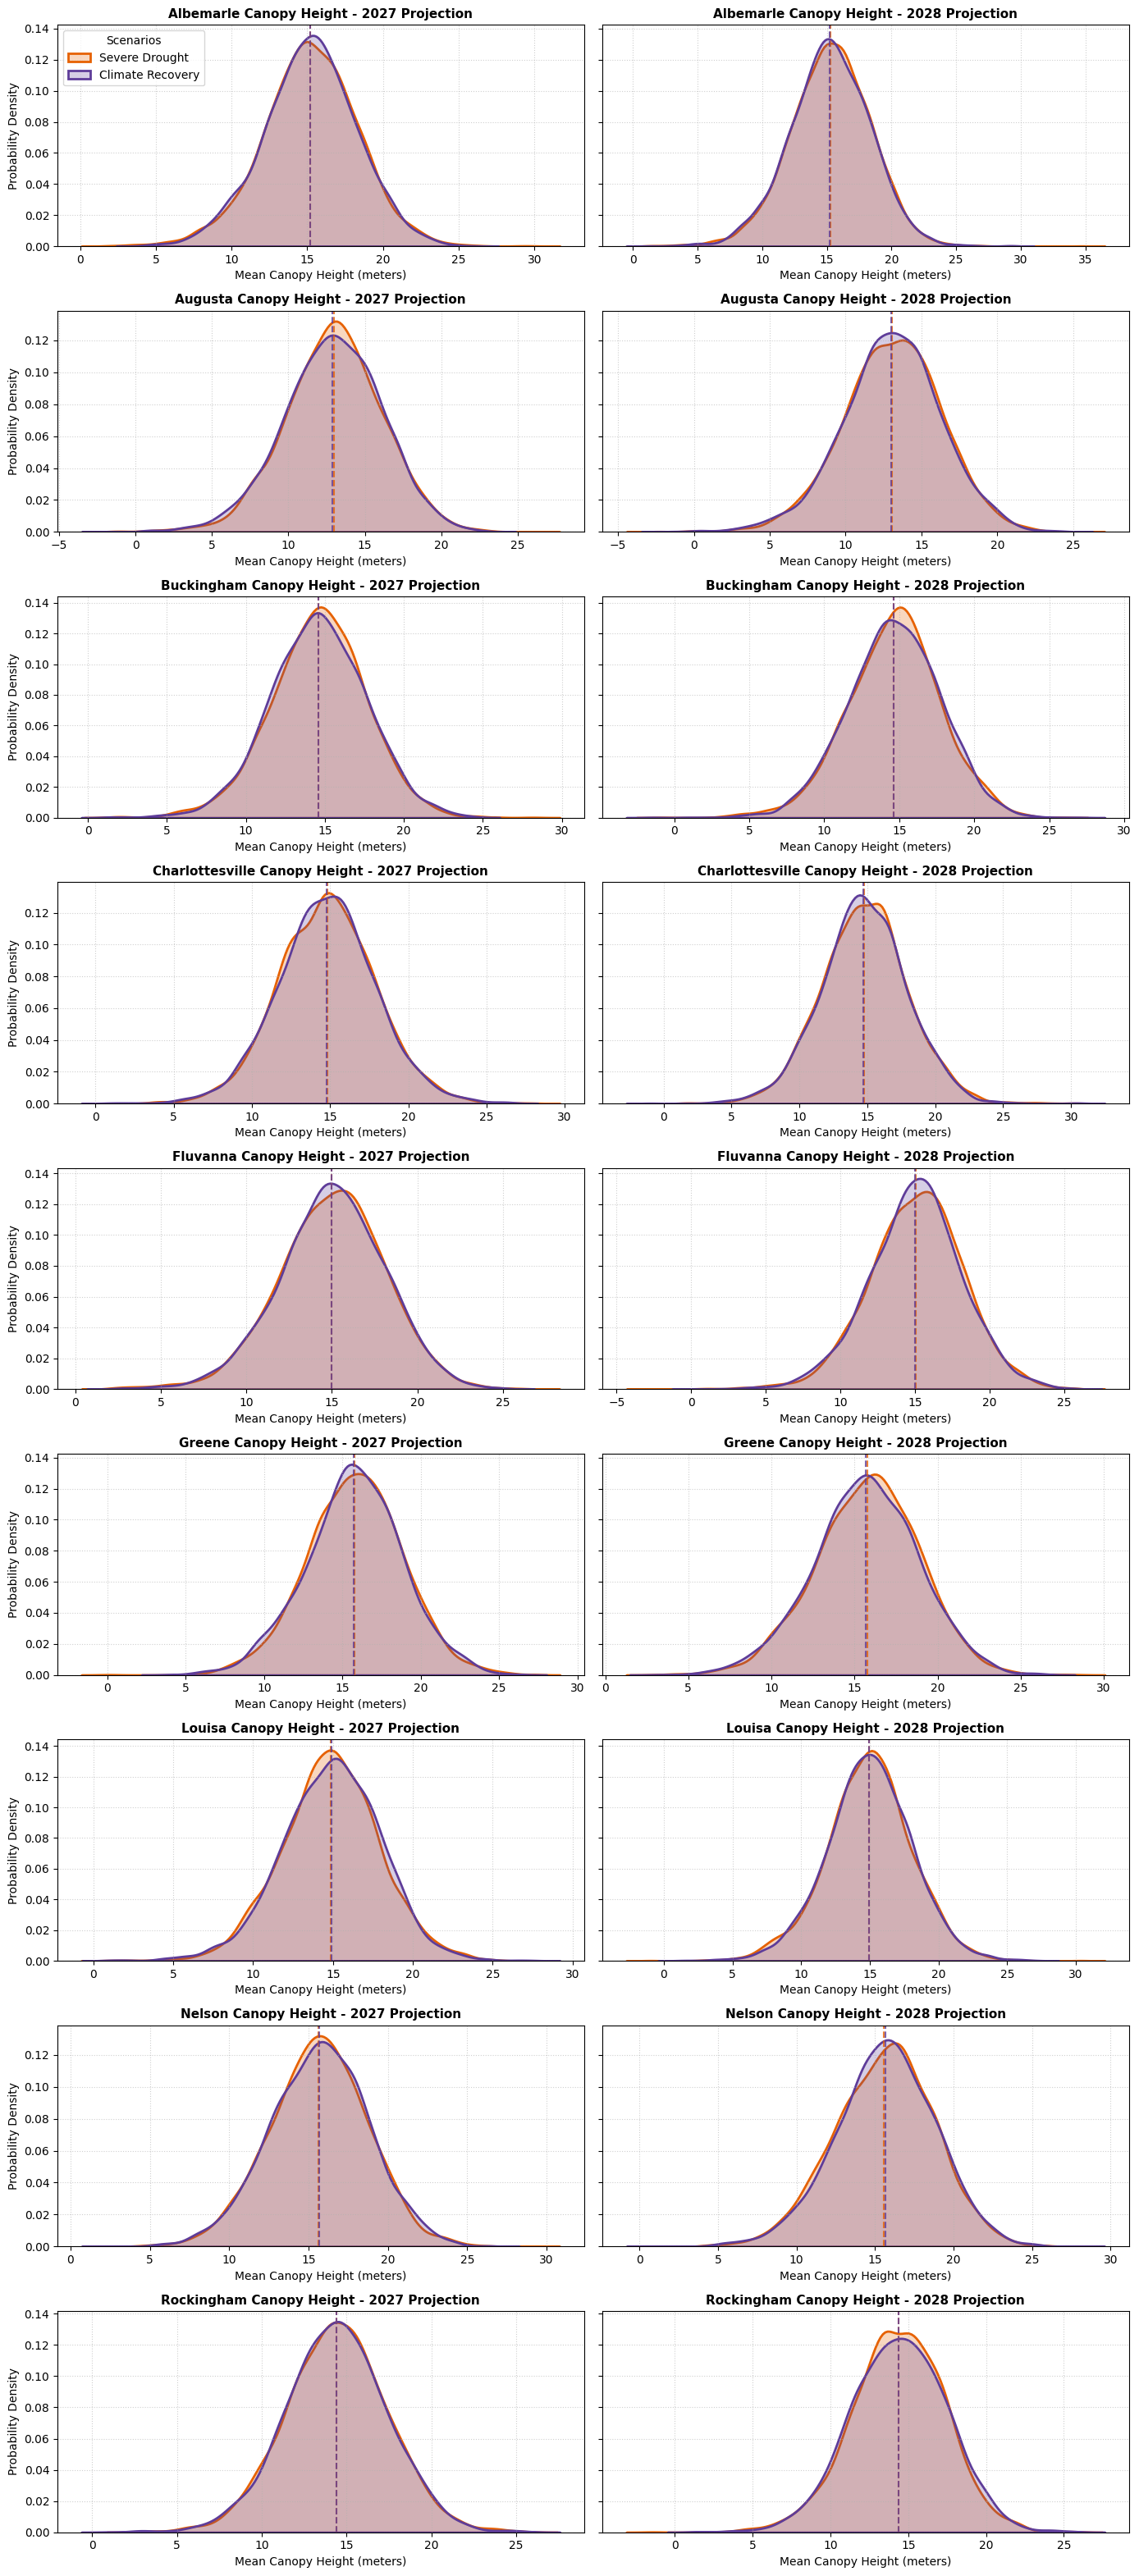

In [14]:
# Run the visualization pipeline using the outputs generated from the scenario loop
plot_bayesian_forecasts(simulation_results, jurisdictions)

In [15]:
# Run the evaluation engine
risk_summary_table = evaluate_canopy_decline_probabilities(simulation_results, jurisdictions, init_canopy)

In [16]:
# Render the formatted breakdown
print("\n================== BAYESIAN CANOPY RISK ASSESSMENT REPORT ==================")
print(risk_summary_table.to_string(index=False))


================== BAYESIAN CANOPY RISK ASSESSMENT REPORT ==================
   Jurisdiction         Scenario  Baseline Height (m)  2027 Decline Risk (%)  2028 Decline Risk (%)  Net Shift by 2028 (m)
      Albemarle   Severe Drought                13.61                   29.2                   28.8                   1.66
      Albemarle Climate Recovery                13.61                   28.9                   28.9                   1.61
        Augusta   Severe Drought                 8.28                    7.3                    7.0                   4.78
        Augusta Climate Recovery                 8.28                    8.0                    7.3                   4.74
     Buckingham   Severe Drought                12.51                   23.4                   23.6                   2.11
     Buckingham Climate Recovery                12.51                   24.7                   23.9                   2.13
Charlottesville   Severe Drought                16.11        